<a href="https://colab.research.google.com/github/OlajideFemi/Carbon-Footprint/blob/main/fluids.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Non-linear fluid dynamics: simulate the Lorenz system

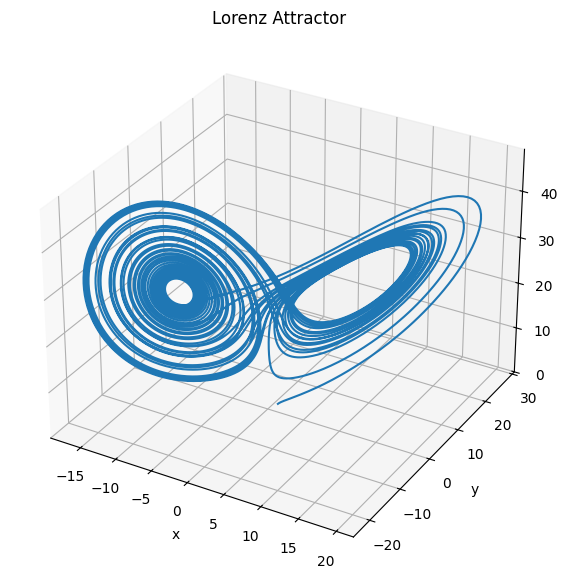

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def lorenz(t, state, sigma=10, rho=28, beta=8 / 3):
    x, y, z = state

    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z

    return [dx, dy, dz]


time = np.linspace(0, 40, 10_000)

solution = solve_ivp(
    lorenz,
    t_span=(time[0], time[-1]),
    y0=[1, 1, 1],
    t_eval=time
)

x, y, z = solution.y

figure = plt.figure(figsize=(9, 7))
axis = figure.add_subplot(111, projection="3d")
axis.plot(x, y, z)
axis.set_title("Lorenz Attractor")
axis.set_xlabel("x")
axis.set_ylabel("y")
axis.set_zlabel("z")
plt.show()

Logigistic-map bifurcation

How simple rules produce chaos

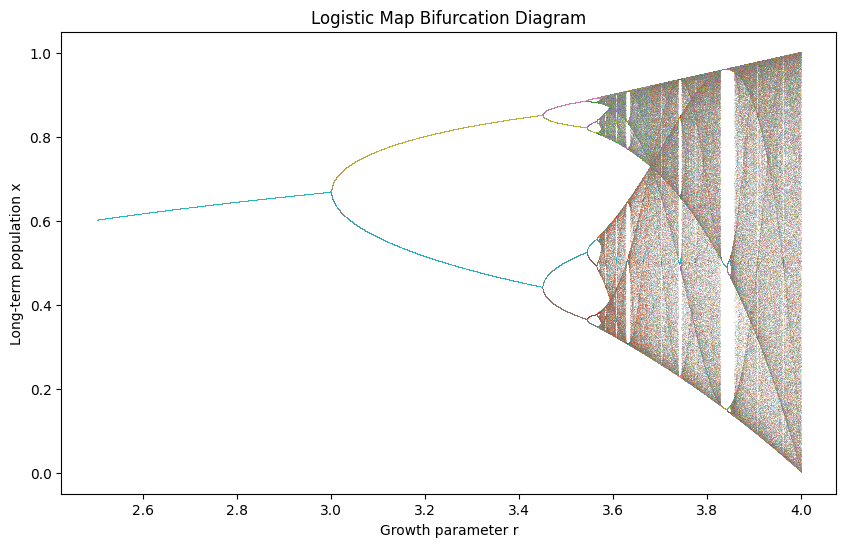

In [2]:
import numpy as np
import matplotlib.pyplot as plt

r_values = np.linspace(2.5, 4.0, 8_000)
x = np.full_like(r_values, 0.5)

iterations = 1_500
keep_last = 150

plt.figure(figsize=(10, 6))

for iteration in range(iterations):
    x = r_values * x * (1 - x)

    if iteration >= iterations - keep_last:
        plt.plot(
            r_values,
            x,
            ",",
            alpha=0.2
        )

plt.title("Logistic Map Bifurcation Diagram")
plt.xlabel("Growth parameter r")
plt.ylabel("Long-term population x")
plt.show()

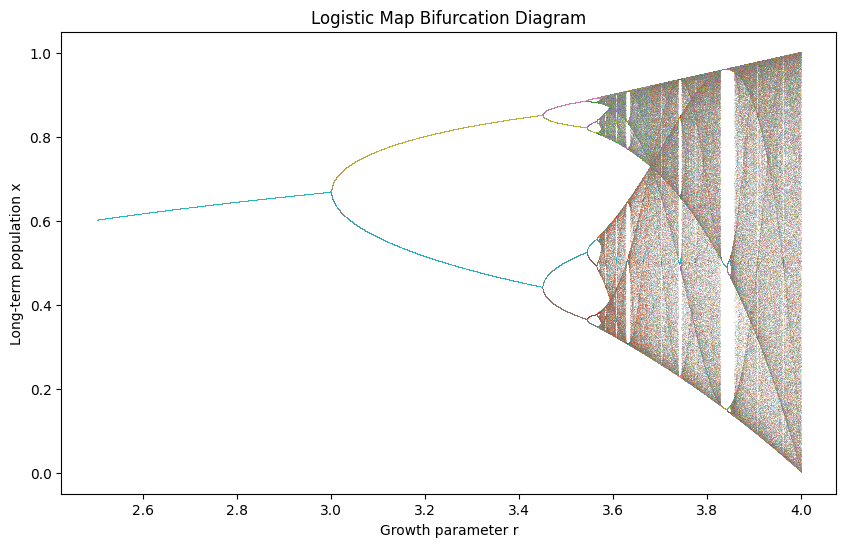

In [3]:
import numpy as np
import matplotlib.pyplot as plt

r_values = np.linspace(2.5, 4.0, 8_000)
x = np.full_like(r_values, 0.5)

iterations = 1_500
keep_last = 150

plt.figure(figsize=(10, 6))

for iteration in range(iterations):
    x = r_values * x * (1 - x)

    if iteration >= iterations - keep_last:
        plt.plot(
            r_values,
            x,
            ",",
            alpha=0.2
        )

plt.title("Logistic Map Bifurcation Diagram")
plt.xlabel("Growth parameter r")
plt.ylabel("Long-term population x")
plt.show()

Mean velocity: 9.99 m/s
Turbulence intensity: 13.43%


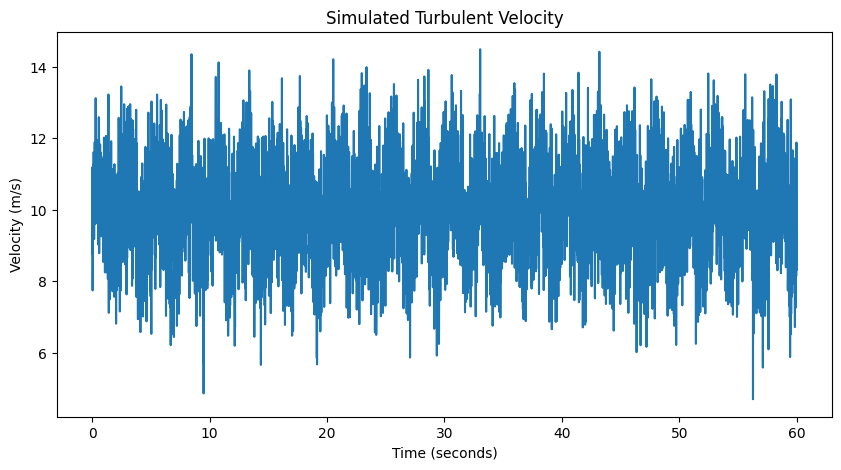

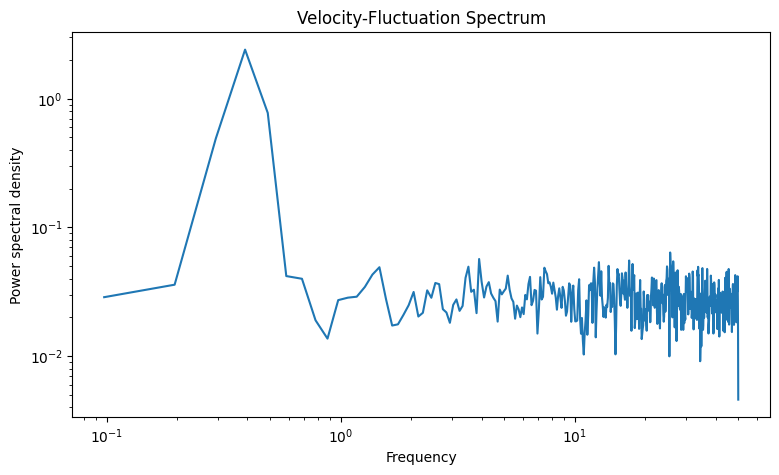

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

rng = np.random.default_rng(42)

sampling_rate = 100
duration = 60
time = np.arange(0, duration, 1 / sampling_rate)

mean_velocity = 10

low_frequency_motion = 0.8 * np.sin(2 * np.pi * 0.4 * time)
random_fluctuation = rng.normal(0, 1.2, len(time))

velocity = mean_velocity + low_frequency_motion + random_fluctuation

average_velocity = velocity.mean()
fluctuation = velocity - average_velocity
rms_fluctuation = np.sqrt(np.mean(fluctuation**2))
turbulence_intensity = rms_fluctuation / average_velocity

frequency, power = welch(
    fluctuation,
    fs=sampling_rate,
    nperseg=1024
)

print(f"Mean velocity: {average_velocity:.2f} m/s")
print(f"Turbulence intensity: {turbulence_intensity:.2%}")

plt.figure(figsize=(10, 5))
plt.plot(time, velocity)
plt.xlabel("Time (seconds)")
plt.ylabel("Velocity (m/s)")
plt.title("Simulated Turbulent Velocity")
plt.show()

plt.figure(figsize=(9, 5))
plt.loglog(frequency[1:], power[1:])
plt.xlabel("Frequency")
plt.ylabel("Power spectral density")
plt.title("Velocity-Fluctuation Spectrum")
plt.show()